# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np

In [2]:
dados_expres = np.random.normal(loc=0.0, scale=1.0, size=1_000)
dados_expres.shape

(1000,)

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [3]:
dados_pacientes = np.random.randint(low=2, high=1_000, size=len(dados_expres))
dados_pacientes.shape

(1000,)

In [4]:
import pandas as pd

In [5]:
df_dados = pd.DataFrame(
    data={
        "expressao_genica": dados_expres,
        "num_genes": dados_pacientes,
    }
)
df_dados.head()

,expressao_genica,num_genes
0,-0.460819,684
1,-0.184209,177
2,1.337016,640
3,0.267164,200
4,-0.172329,963


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os dados de expressão gênica serão separados de acordo com os quartis.

In [6]:
df_dados.describe()

,expressao_genica,num_genes
count,1000.000000,1000.000000
mean,0.004179,485.715000
std,0.980459,281.025538
min,-2.877447,2.000000
25%,-0.640397,244.750000
50%,0.036542,488.000000
75%,0.651106,709.250000
max,3.913332,998.000000


In [7]:
cat = 0
bin = df_dados[df_dados.columns[cat]].quantile([0, 0.25, 0.5, 0.75, 1]).values
bin = np.insert(bin, 0, -10)
bin = np.insert(bin, 6, 10)
bin

array([-10.        ,  -2.87744665,  -0.64039686,   0.03654174,
         0.6511056 ,   3.91333235,  10.        ])

In [8]:
label = ["nivel_1", "nivel_2", "nivel_3", "nivel_4", "nivel_5", "nivel_6"]
df_dados[df_dados.columns[cat]+"_cat"] = pd.cut(x=df_dados[df_dados.columns[cat]], bins=bin, labels=label)
df_dados.head()

,expressao_genica,num_genes,expressao_genica_cat
0,-0.460819,684,nivel_3
1,-0.184209,177,nivel_3
2,1.337016,640,nivel_5
3,0.267164,200,nivel_4
4,-0.172329,963,nivel_3


In [9]:
cat = 1
bin = df_dados[df_dados.columns[cat]].quantile([0, 0.25, 0.5, 0.75, 1]).values
bin = np.insert(bin, 0, -1)
bin = np.insert(bin, 6, 2_000)
bin

array([-1.0000e+00,  2.0000e+00,  2.4475e+02,  4.8800e+02,  7.0925e+02,
        9.9800e+02,  2.0000e+03])

In [10]:
label = ["grupo_1", "grupo_2", "grupo_3", "grupo_4", "grupo_5", "grupo_6"]
df_dados[df_dados.columns[cat]+"_cat"] = pd.cut(x=df_dados[df_dados.columns[cat]], bins=bin, labels=label)
df_dados.head()

,expressao_genica,num_genes,expressao_genica_cat,num_genes_cat
0,-0.460819,684,nivel_3,grupo_4
1,-0.184209,177,nivel_3,grupo_2
2,1.337016,640,nivel_5,grupo_4
3,0.267164,200,nivel_4,grupo_2
4,-0.172329,963,nivel_3,grupo_5


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [11]:
def tabelar_frequencia(lista_dados: pd.Series) -> pd.DataFrame:
    '''
        Função para criar uma tabela de frequência a partir de uma
        Series do pandas.
            Parâmetros:
                lista_dados (pd.Series): A Series do pandas contendo
                                         os dados a serem tabulados
            Retorna:
                pd.DataFrame: Uma tabela de frequência com as colunas 
                                "Freq Abso Simp", "Freq Rela Simp", 
                                "Freq Abso Acum" e "Freq Rela Acum"
    '''
    if type(lista_dados) != pd.Series:
        raise TypeError("A entrada deve ser uma Series do pandas.")
    else:
        lista_dados = pd.DataFrame(
                                    data=lista_dados.value_counts().values,
                                    index=lista_dados.value_counts().index,
                                    columns=["Freq Abso Simp"],
                                    ).sort_index()
        lista_dados["Freq Rela Simp"] = lista_dados["Freq Abso Simp"] / lista_dados["Freq Abso Simp"].sum()
        lista_dados["Freq Abso Acum"] = lista_dados["Freq Abso Simp"].cumsum()
        lista_dados["Freq Rela Acum"] = lista_dados["Freq Rela Simp"].cumsum()
        lista_dados.loc['Total'] = [lista_dados["Freq Abso Simp"].sum(), lista_dados["Freq Rela Simp"].sum(), np.nan, np.nan]
        return lista_dados.round(2)

In [12]:
try:
    tabelar_frequencia(lista_dados = [1, 2, 3, 4, 5])
except Exception as e:
    print(e)

A entrada deve ser uma Series do pandas.


In [13]:
try:
    tabela_freq = tabelar_frequencia(lista_dados = pd.Series([1, 1, 2, 2, 3, 3, 3, 4, 5]))
    print(tabela_freq)
except Exception as e:
    print(e)

       Freq Abso Simp  Freq Rela Simp  Freq Abso Acum  Freq Rela Acum
1                 2.0            0.22             2.0            0.22
2                 2.0            0.22             4.0            0.44
3                 3.0            0.33             7.0            0.78
4                 1.0            0.11             8.0            0.89
5                 1.0            0.11             9.0            1.00
Total             9.0            1.00             NaN             NaN


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df_dados.head()

,expressao_genica,num_genes,expressao_genica_cat,num_genes_cat
0,-0.460819,684,nivel_3,grupo_4
1,-0.184209,177,nivel_3,grupo_2
2,1.337016,640,nivel_5,grupo_4
3,0.267164,200,nivel_4,grupo_2
4,-0.172329,963,nivel_3,grupo_5


### Expressão

In [16]:
df_expr_ordinal = tabelar_frequencia(lista_dados=df_dados[df_dados.columns[2]])
df_expr_ordinal

,Freq Abso Simp,Freq Rela Simp,Freq Abso Acum,Freq Rela Acum
nivel_1,1.0,0.00,1.0,0.00
nivel_2,249.0,0.25,250.0,0.25
nivel_3,250.0,0.25,500.0,0.50
nivel_4,250.0,0.25,750.0,0.75
nivel_5,250.0,0.25,1000.0,1.00
nivel_6,0.0,0.00,1000.0,1.00
Total,1000.0,1.00,NaN,NaN


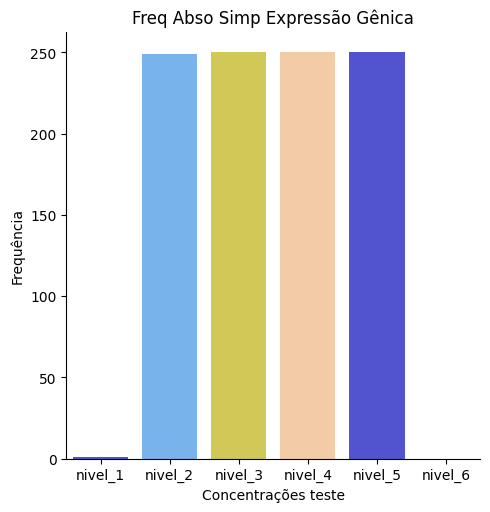

In [17]:
custom_palette = ["#3C3FE4", '#66B3FF', "#E4D943", '#FFCC99']  # Custom pastel colors
cat = 0
sns.catplot(
    kind='bar',
    x=list(df_expr_ordinal[df_expr_ordinal.columns[cat]].index)[:-1],
    y=df_expr_ordinal.columns[cat],
    data=df_expr_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title(f"{df_expr_ordinal.columns[cat]} Expressão Gênica")
plt.show()

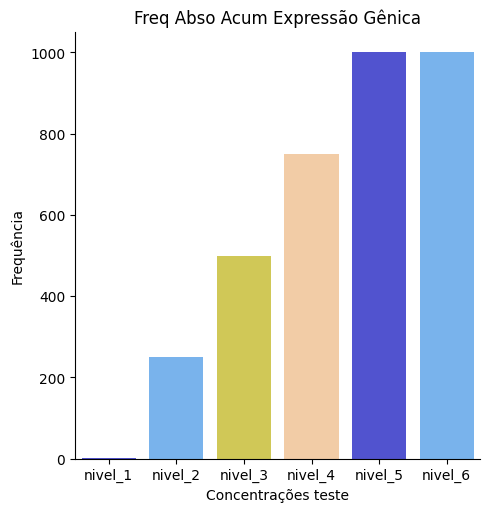

In [18]:
cat = 2
sns.catplot(
    kind='bar',
    x=list(df_expr_ordinal[df_expr_ordinal.columns[cat]].index)[:-1],
    y=df_expr_ordinal.columns[cat],
    data=df_expr_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title(f"{df_expr_ordinal.columns[cat]} Expressão Gênica")
plt.show()

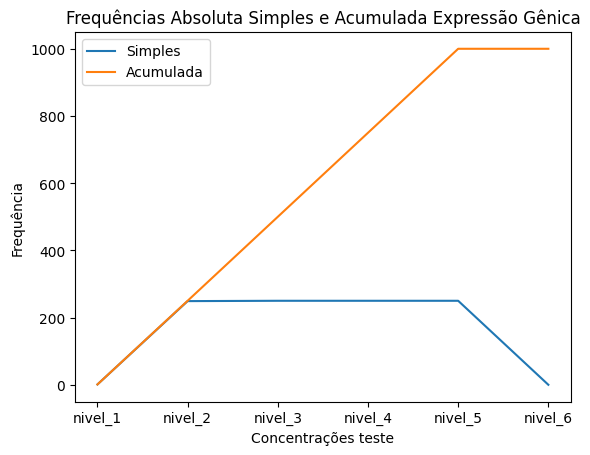

In [19]:
df_expr_ordinal.iloc[:-1][[df_expr_ordinal.columns[0],df_expr_ordinal.columns[2]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Absoluta Simples e Acumulada Expressão Gênica")
plt.legend(['Simples', 'Acumulada'])
plt.show()

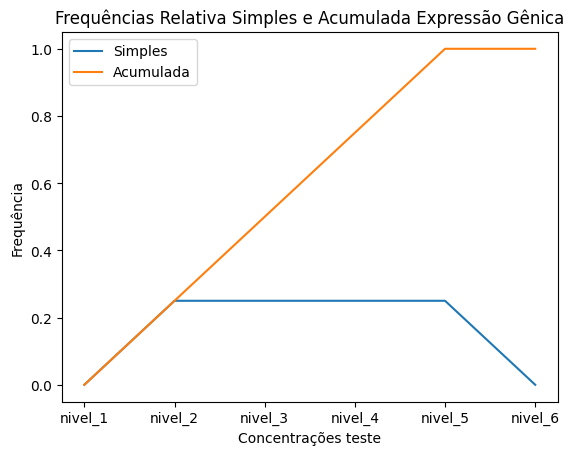

In [20]:
df_expr_ordinal.iloc[:-1][[df_expr_ordinal.columns[1],df_expr_ordinal.columns[3]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Simples e Acumulada Expressão Gênica")
plt.legend(['Simples', 'Acumulada'])
plt.show()

### Número

In [21]:
df_num_ordinal = tabelar_frequencia(lista_dados=df_dados[df_dados.columns[3]])
df_num_ordinal

,Freq Abso Simp,Freq Rela Simp,Freq Abso Acum,Freq Rela Acum
grupo_1,1.0,0.00,1.0,0.00
grupo_2,249.0,0.25,250.0,0.25
grupo_3,251.0,0.25,501.0,0.50
grupo_4,249.0,0.25,750.0,0.75
grupo_5,250.0,0.25,1000.0,1.00
grupo_6,0.0,0.00,1000.0,1.00
Total,1000.0,1.00,NaN,NaN


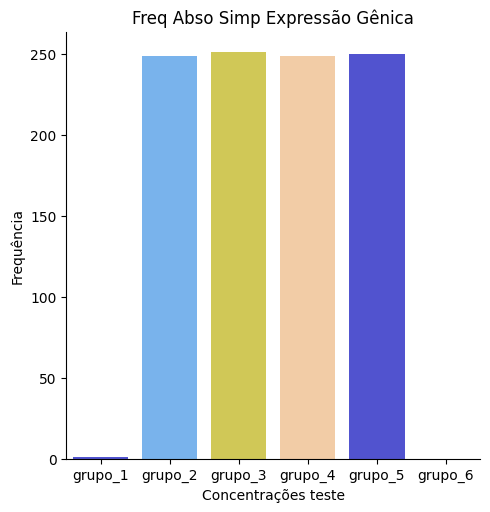

In [22]:
custom_palette = ["#3C3FE4", '#66B3FF', "#E4D943", '#FFCC99']  # Custom pastel colors
cat = 0
sns.catplot(
    kind='bar',
    x=list(df_num_ordinal[df_num_ordinal.columns[cat]].index)[:-1],
    y=df_num_ordinal.columns[cat],
    data=df_num_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title(f"{df_num_ordinal.columns[cat]} Expressão Gênica")
plt.show()

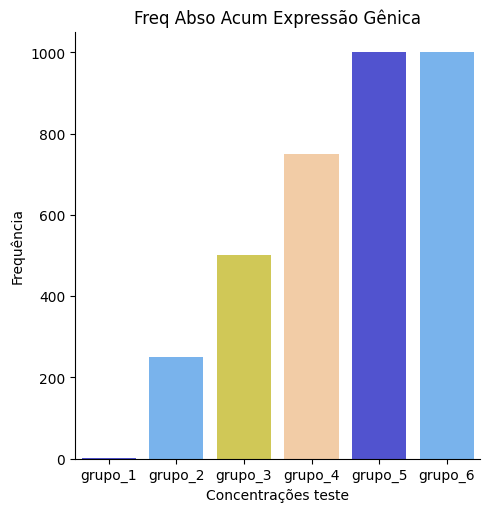

In [23]:
cat = 2
sns.catplot(
    kind='bar',
    x=list(df_num_ordinal[df_num_ordinal.columns[cat]].index)[:-1],
    y=df_num_ordinal.columns[cat],
    data=df_num_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title(f"{df_num_ordinal.columns[cat]} Expressão Gênica")
plt.show()

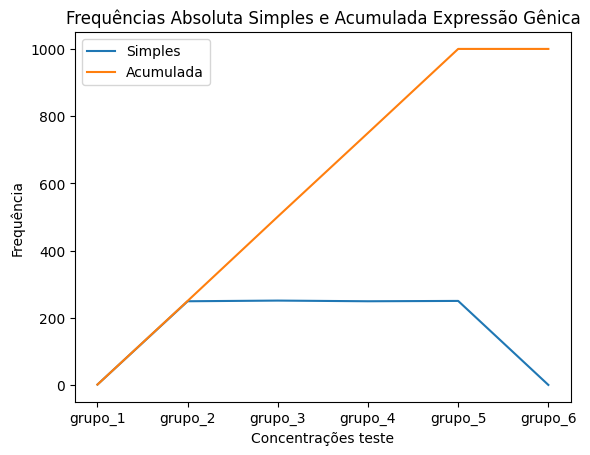

In [24]:
df_num_ordinal.iloc[:-1][[df_num_ordinal.columns[0],df_num_ordinal.columns[2]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Absoluta Simples e Acumulada Expressão Gênica")
plt.legend(['Simples', 'Acumulada'])
plt.show()

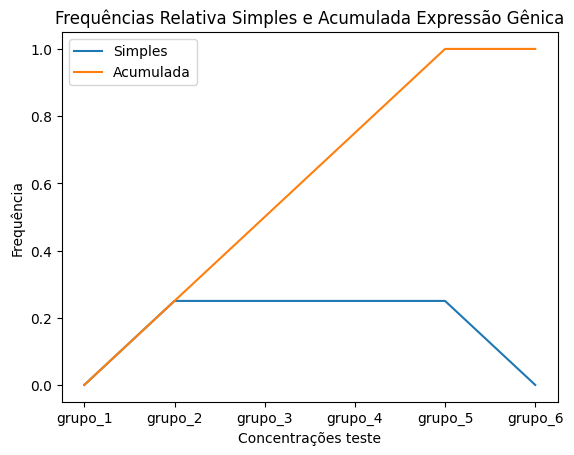

In [25]:
df_num_ordinal.iloc[:-1][[df_num_ordinal.columns[1],df_num_ordinal.columns[3]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Simples e Acumulada Expressão Gênica")
plt.legend(['Simples', 'Acumulada'])
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

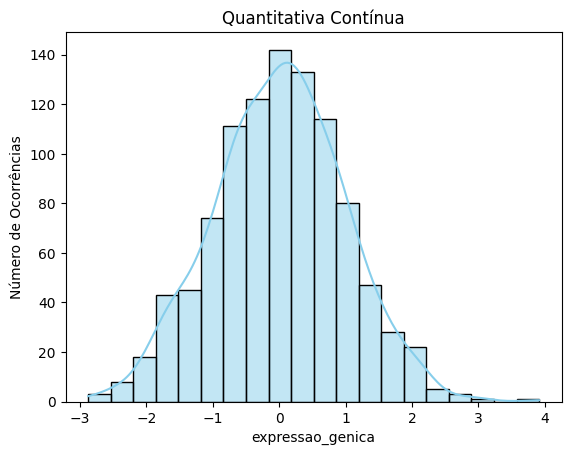

In [26]:
sns.histplot(
    x=df_dados.columns[0],
    kde=True,
    bins=20,
    color='skyblue',
    data=df_dados,
)
plt.title("Quantitativa Contínua")
plt.xlabel(df_dados.columns[0])
plt.ylabel("Número de Ocorrências")
plt.show()

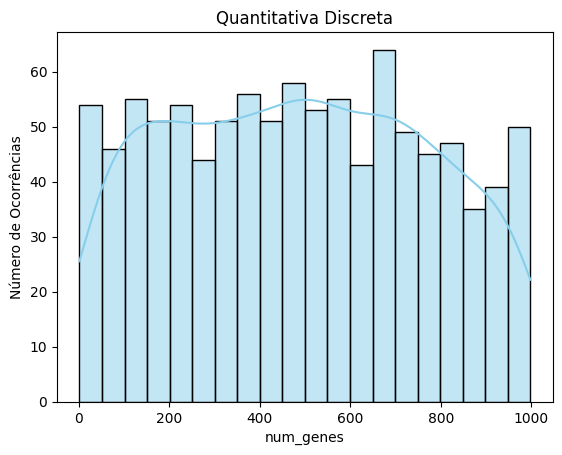

In [27]:
sns.histplot(
    x=df_dados.columns[1],
    kde=True,
    bins=20,
    color='skyblue',
    data=df_dados,
)
plt.title("Quantitativa Discreta")
plt.xlabel(df_dados.columns[1])
plt.ylabel("Número de Ocorrências")
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

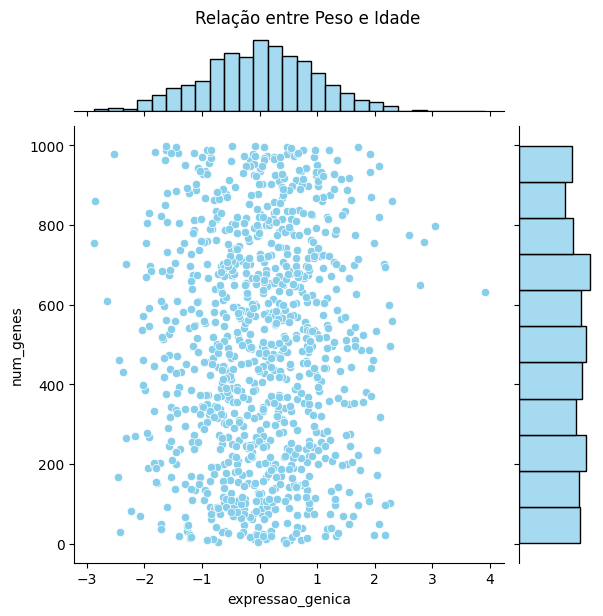

In [28]:
sns.jointplot(
    x=df_dados.columns[0],
    y=df_dados.columns[1],
    data=df_dados,
    kind='scatter',
    color='skyblue',
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(df_dados.columns[0])
plt.ylabel(df_dados.columns[1])
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

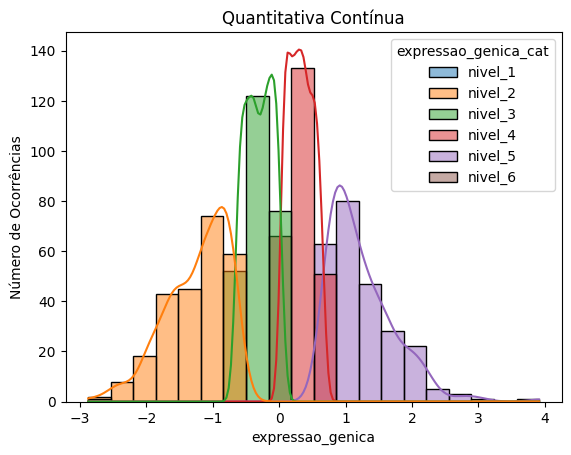

In [29]:
sns.histplot(
    x=df_dados.columns[0],
    kde=True,
    bins=20,
    color='skyblue',
    hue=df_dados.columns[2],
    data=df_dados,
)
plt.title("Quantitativa Contínua")
plt.xlabel(df_dados.columns[0])
plt.ylabel("Número de Ocorrências")
plt.show()

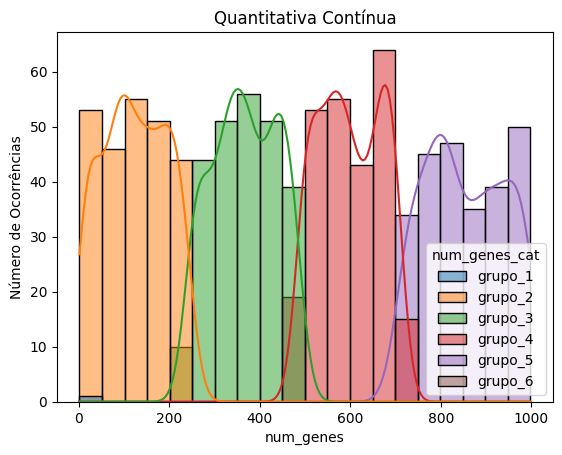

In [30]:
sns.histplot(
    x=df_dados.columns[1],
    kde=True,
    bins=20,
    color='skyblue',
    hue=df_dados.columns[3],
    data=df_dados,
)
plt.title("Quantitativa Contínua")
plt.xlabel(df_dados.columns[1])
plt.ylabel("Número de Ocorrências")
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

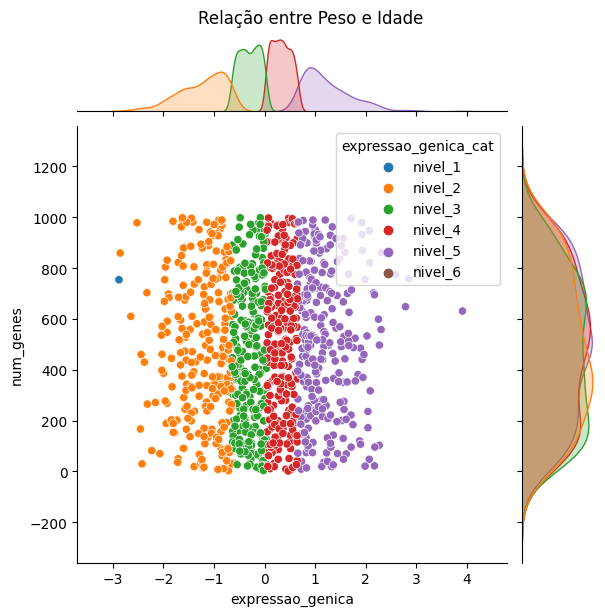

In [31]:
sns.jointplot(
    x=df_dados.columns[0],
    y=df_dados.columns[1],
    data=df_dados,
    kind='scatter',
    hue=df_dados.columns[2],
    color='skyblue',
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(df_dados.columns[0])
plt.ylabel(df_dados.columns[1])
plt.show()

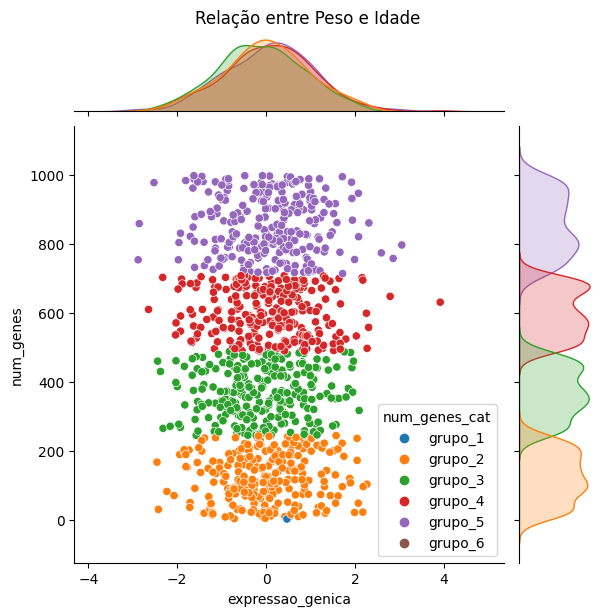

In [32]:
sns.jointplot(
    x=df_dados.columns[0],
    y=df_dados.columns[1],
    data=df_dados,
    kind='scatter',
    hue=df_dados.columns[3],
    color='skyblue',
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(df_dados.columns[0])
plt.ylabel(df_dados.columns[1])
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|Discreta|
| % de células positivas|Contínua|
| Faixa de pH|Ordinal|
| Valor de pH|Contínua|
| mol/L|Contínua|
| UFC|Discreta|
| D.O.|Contínua|
| Grupo Sanguíneo|Nominal|
| Sorologia|Nominal|